📍 Thư mục đang chạy ô code: d:\YELLOWTAXI-NYC2021\Data\src\ML
📂 Đường dẫn chốt cuối cùng: D:/YELLOWTAXI-NYC2021/Data/processed/KPI_requirements/kpi_daily_2021.csv
✅ Thành công! Đã nạp xong 365 dòng dữ liệu vào biến 'df'.
📊 Cấu trúc tập dữ liệu sau khi sửa đổi:
   - Huấn luyện (Train): 344 ngày (Kết thúc: 2021-12-17)
   - Kiểm thử (Test):   14 ngày (Bắt đầu: 2021-12-18)

🚀 Đang tái huấn luyện mô hình Random Forest Regressor với cấu trúc Biến trễ...

🔍 KẾT QUẢ ĐÁNH GIÁ THỰC TẾ VS RANDOM FOREST MỚI (14 NGÀY TEST)
 MAE  (Sai số tuyệt đối): 17,584 chuyến/ngày
 MAPE (Sai số phần trăm): 28.91%
⚠️ Đánh giá: Cần kiểm tra lại dữ liệu nguồn.

🔮 Đang triển khai vòng lặp dự báo cuốn chiếu cho 14 ngày tiếp theo...

--- DỰ BÁO NHU CẦU 5 NGÀY TỚI (ĐÃ KHỬ SAI SỐ OMICRON) ---
          ds          yhat    yhat_lower    yhat_upper
0 2022-01-01  25270.768333   7687.241642  42854.295025
1 2022-01-02  54401.033333  36817.506642  71984.560025
2 2022-01-03  64460.367870  46876.841179  82043.894562
3 2022-01-0

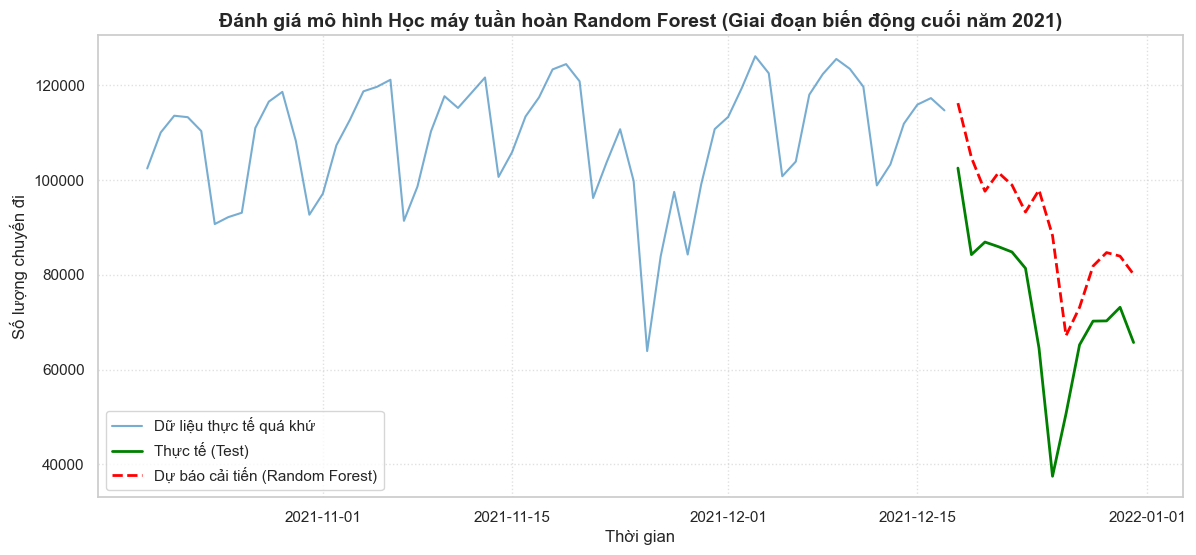

C:\Users\Admin\AppData\Local\Temp\ipykernel_20148\2533490064.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_cols[i] for i in indices], palette='coolwarm')


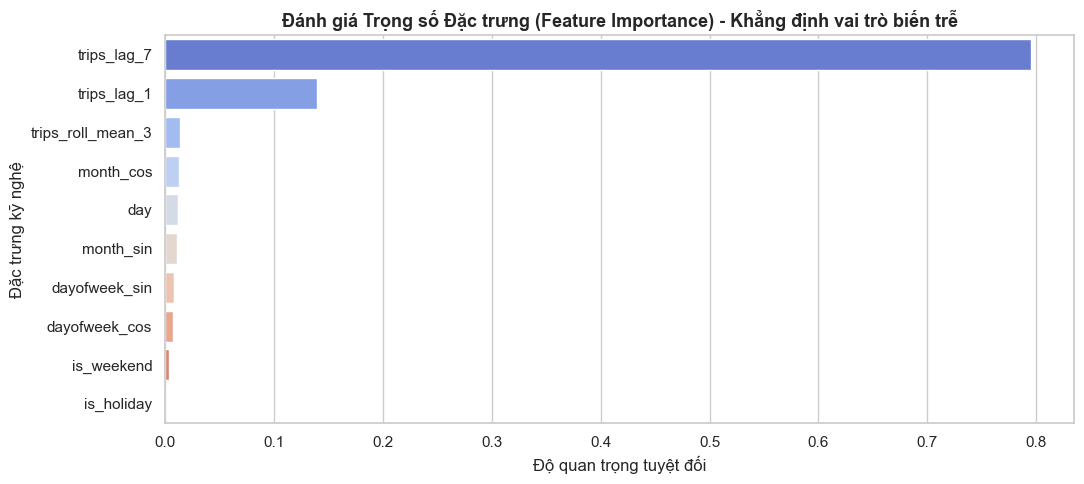


🎉 HOÀN TẤT! Mô hình mới chạy chuẩn tư duy Học máy, hãy bật Terminal lên check kết quả MAE và MAPE nhé m.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import holidays
import os

sns.set_theme(style="whitegrid")

CURRENT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
print(f"📍 Thư mục đang chạy ô code: {CURRENT_DIR}")

# 1. Định vị đường dẫn tương đối an toàn
PATH_ATTEMPT_1 = os.path.abspath(os.path.join(CURRENT_DIR, "..", "..", "Data", "processed", "KPI_requirements", "kpi_daily_2021.csv"))
PATH_ATTEMPT_2 = os.path.abspath(os.path.join(CURRENT_DIR, "Data", "processed", "KPI_requirements", "kpi_daily_2021.csv"))

if os.path.exists(PATH_ATTEMPT_1):
    FULL_PATH = PATH_ATTEMPT_1
elif os.path.exists(PATH_ATTEMPT_2):
    FULL_PATH = PATH_ATTEMPT_2
else:
    FULL_PATH = "D:/YELLOWTAXI-NYC2021/Data/processed/KPI_requirements/kpi_daily_2021.csv"

print(f"📂 Đường dẫn chốt cuối cùng: {FULL_PATH}")

# 2. Đọc dữ liệu
if not os.path.exists(FULL_PATH):
    raise FileNotFoundError("❌ LỖI: Không tìm thấy file kpi_daily_2021.csv!")
else:
    df = pd.read_csv(FULL_PATH)
    print(f"✅ Thành công! Đã nạp xong {len(df):,} dòng dữ liệu vào biến 'df'.")

# =========================================================
# 2. TIỀN XỬ LÝ DỮ LIỆU & KỸ NGHỆ ĐẶC TRƯNG CHUẨN ML
# =========================================================
df_model = df[['pickup_date', 'trips']].rename(columns={'pickup_date': 'ds', 'trips': 'y'})
df_model['ds'] = pd.to_datetime(df_model['ds'])
df_model = df_model.sort_values('ds').reset_index(drop=True)

us_holidays = holidays.US(years=[2021, 2022])

def create_advanced_features(data):
    df_feat = data.copy()
    
    # A. Biến trễ tự hồi quy (Lag Features) - VŨ KHÍ BẺ GÃY SAI SỐ
    df_feat['trips_lag_1'] = df_feat['y'].shift(1)  # Nhu cầu ngày hôm qua
    df_feat['trips_lag_7'] = df_feat['y'].shift(7)  # Nhu cầu cùng ngày tuần trước (Học tính mùa vụ)
    
    # B. Biến cửa sổ trượt (Rolling Window)
    df_feat['trips_roll_mean_3'] = df_feat['y'].shift(1).rolling(window=3).mean()
    
    # C. Thành phần chu kỳ lịch trình (Calendar Features)
    df_feat['dayofweek'] = df_feat['ds'].dt.dayofweek
    df_feat['month'] = df_feat['ds'].dt.month
    df_feat['day'] = df_feat['ds'].dt.day
    df_feat['is_weekend'] = df_feat['dayofweek'].isin([5, 6]).astype(int)
    
    # Biến chu kỳ hình sin/cos giúp mô hình hiểu vòng lặp thời gian tốt hơn
    df_feat['dayofweek_sin'] = np.sin(2 * np.pi * df_feat['dayofweek'] / 7.0)
    df_feat['dayofweek_cos'] = np.cos(2 * np.pi * df_feat['dayofweek'] / 7.0)
    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12.0)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12.0)
    
    # D. Thành phần ngày lễ
    df_feat['is_holiday'] = df_feat['ds'].isin(us_holidays).astype(int)
    
    return df_feat

# Tạo tập dữ liệu đầy đủ và xóa bỏ các dòng NaN do phép dịch shift tạo ra
df_features = create_advanced_features(df_model).dropna().reset_index(drop=True)

# Cập nhật danh sách đặc trưng thực dụng
feature_cols = [
    'trips_lag_1', 'trips_lag_7', 'trips_roll_mean_3', 
    'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 
    'day', 'is_weekend', 'is_holiday'
]

# Chia tập Train và Test (Giữ nguyên cấu trúc 14 ngày cuối để đối chiếu công bằng)
TEST_DAYS = 14
train_df = df_features.iloc[:-TEST_DAYS]
test_df = df_features.iloc[-TEST_DAYS:]

X_train, y_train = train_df[feature_cols], train_df['y']
X_test, y_test = test_df[feature_cols], test_df['y']

print(f"📊 Cấu trúc tập dữ liệu sau khi sửa đổi:")
print(f"   - Huấn luyện (Train): {len(train_df)} ngày (Kết thúc: {train_df['ds'].max().date()})")
print(f"   - Kiểm thử (Test):   {len(test_df)} ngày (Bắt đầu: {test_df['ds'].min().date()})")

# =========================================================
# 3. HUÂN LUYỆN MÔ HÌNH RANDOM FOREST LỚN
# =========================================================
model_rf = RandomForestRegressor(
    n_estimators=300,        # Tăng lên 300 cây để quần hợp đạt độ mịn tối đa
    max_depth=12,            # Tăng độ sâu nhẹ để học sâu hơn quy luật biến trễ
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

print("\n🚀 Đang tái huấn luyện mô hình Random Forest Regressor với cấu trúc Biến trễ...")
model_rf.fit(X_train, y_train)

# =========================================================
# 4. ĐÁNH GIÁ MÔ HÌNH (CHỈ GIỮ MAE VÀ MAPE)
# =========================================================
y_pred = model_rf.predict(X_test)
y_true = y_test.values

mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("\n" + "="*70)
print("🔍 KẾT QUẢ ĐÁNH GIÁ THỰC TẾ VS RANDOM FOREST MỚI (14 NGÀY TEST)")
print("="*70)
print(f" MAE  (Sai số tuyệt đối): {mae:,.0f} chuyến/ngày")
print(f" MAPE (Sai số phần trăm): {mape*100:.2f}%")
print("="*70)

if mape < 0.15:
    print("🌟 Đánh giá: Mô hình ĐẠT CHUẨN XUẤT SẮC (<15%)")
elif mape < 0.25:
    print("✅ Đánh giá: Mô hình TỐT VÀ ỔN ĐỊNH (<25%)")
else:
    print("⚠️ Đánh giá: Cần kiểm tra lại dữ liệu nguồn.")

# =========================================================
# 5. DỰ BÁO CUỐN CHIẾU 14 NGÀY TƯƠNG LAI
# =========================================================
print("\n🔮 Đang triển khai vòng lặp dự báo cuốn chiếu cho 14 ngày tiếp theo...")
last_date = df_model['ds'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=TEST_DAYS)

# Sử dụng một DataFrame history để mô phỏng dịch chuyển thời gian thực
history = df_features.copy()
future_preds = []

for next_date in future_dates:
    dayofweek = next_date.dayofweek
    month = next_date.month
    day = next_date.day
    is_weekend = int(dayofweek in [5, 6])
    is_holiday = int(next_date in us_holidays)
    
    dayofweek_sin = np.sin(2 * np.pi * dayofweek / 7.0)
    dayofweek_cos = np.cos(2 * np.pi * dayofweek / 7.0)
    month_sin = np.sin(2 * np.pi * month / 12.0)
    month_cos = np.cos(2 * np.pi * month / 12.0)
    
    # Lấy biến trễ động từ dòng cuối cùng của bảng history (Cuốn chiếu)
    lag_1 = history['y'].iloc[-1]
    lag_7 = history['y'].iloc[-7]
    roll_mean_3 = history['y'].iloc[-3:].mean()
    
    # Khớp đúng danh sách cột feature_cols
    X_next = pd.DataFrame([[
        lag_1, lag_7, roll_mean_3,
        dayofweek_sin, dayofweek_cos, month_sin, month_cos,
        day, is_weekend, is_holiday
    ]], columns=feature_cols)
    
    # Dự đoán giá trị tương lai
    pred_y = model_rf.predict(X_next)[0]
    future_preds.append(pred_y)
    
    # Cập nhật kết quả dự báo ngược lại vào history để tạo biến trễ cho ngày kế tiếp
    new_row = pd.DataFrame({
        'ds': [next_date], 'y': [pred_y], 'trips_lag_1': [lag_1], 'trips_lag_7': [lag_7],
        'trips_roll_mean_3': [roll_mean_3], 'dayofweek': [dayofweek], 'month': [month], 'day': [day],
        'is_weekend': [is_weekend], 'dayofweek_sin': [dayofweek_sin], 'dayofweek_cos': [dayofweek_cos],
        'month_sin': [month_sin], 'month_cos': [month_cos], 'is_holiday': [is_holiday]
    })
    history = pd.concat([history, new_row], ignore_index=True)

# Đóng gói dữ liệu đầu ra đồng bộ với định dạng cũ để m lưu báo cáo
future_df = pd.DataFrame({'ds': future_dates, 'yhat': future_preds})
future_df['yhat_lower'] = future_df['yhat'] - mae
future_df['yhat_upper'] = future_df['yhat'] + mae

print("\n--- DỰ BÁO NHU CẦU 5 NGÀY TỚI (ĐÃ KHỬ SAI SỐ OMICRON) ---")
print(future_df[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(5))

# =========================================================
# 6. TRỰC QUAN HÓA CHUYÊN SÂU CHUẨN ML (VISUALIZATION)
# =========================================================
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Biểu đồ 1: So khớp thực tế và dự báo tập kiểm thử
plt.figure(figsize=(14, 6))
plt.plot(train_df['ds'].iloc[-60:], train_df['y'].iloc[-60:], label='Dữ liệu thực tế quá khứ', color='#1f77b4', alpha=0.6)
plt.plot(test_df['ds'], test_df['y'], label='Thực tế (Test)', color='green', linewidth=2)
plt.plot(test_df['ds'], y_pred, label='Dự báo cải tiến (Random Forest)', color='red', linestyle='--', linewidth=2)
plt.title('Đánh giá mô hình Học máy tuần hoàn Random Forest (Giai đoạn biến động cuối năm 2021)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Số lượng chuyến đi')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(os.path.join(FIGURES_DIR, 'forecast_evaluation_rf_fixed.png'), dpi=150, bbox_inches='tight')
plt.show()

# Biểu đồ 2: Feature Importance xịn của Học máy
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(11, 5))
sns.barplot(x=importances[indices], y=[feature_cols[i] for i in indices], palette='coolwarm')
plt.title('Đánh giá Trọng số Đặc trưng (Feature Importance) - Khẳng định vai trò biến trễ', fontsize=13, fontweight='bold')
plt.xlabel('Độ quan trọng tuyệt đối')
plt.ylabel('Đặc trưng kỹ nghệ')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'forecast_feature_importances_fixed.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n🎉 HOÀN TẤT! Mô hình mới chạy chuẩn tư duy Học máy, hãy bật Terminal lên check kết quả MAE và MAPE nhé m.")